In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tmdb-box-office-prediction/sample_submission.csv
/kaggle/input/tmdb-box-office-prediction/train.csv
/kaggle/input/tmdb-box-office-prediction/test.csv


Train shape: (3000, 23)
Test shape: (4398, 22)

Train columns: ['id', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue']


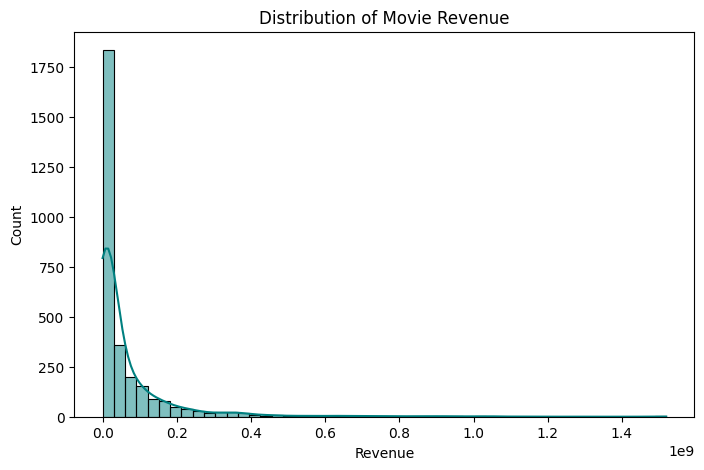

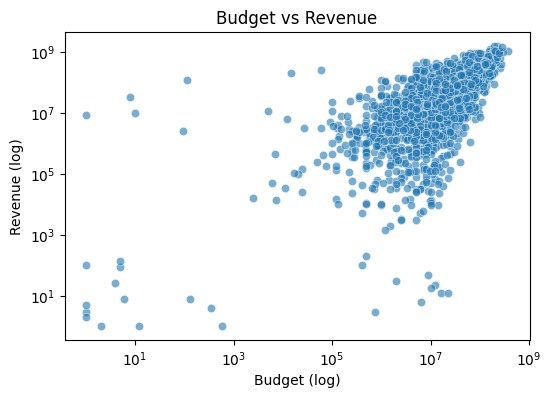

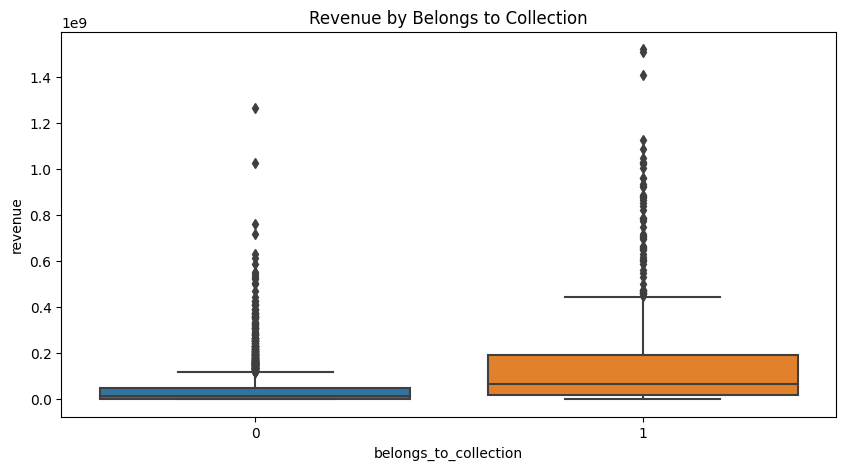


===== Fold 1 =====
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1681
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 17
[LightGBM] [Info] Start training from score 15.922417
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[293]	training's rmse: 1.21225	valid_1's rmse: 2.00865
Fold 1 RMSE: 2.0086

===== Fold 2 =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1663
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 17
[LightGBM] [Info] Start training from score 15.963493
Training until validation scores don't i

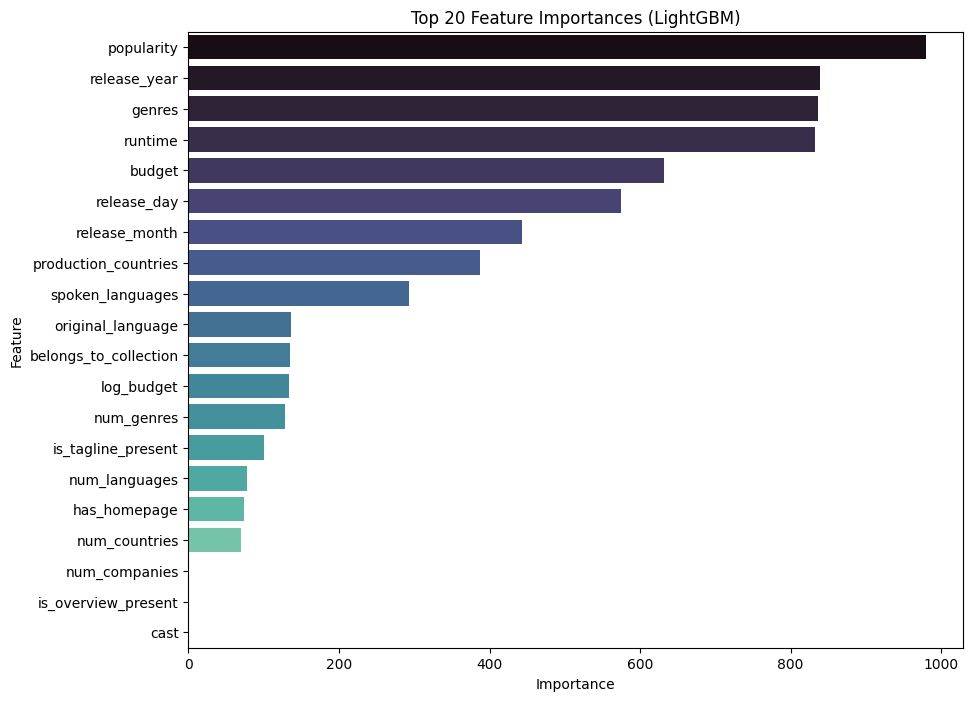


🎉 submission.csv has been created successfully!


In [2]:
# ============================================================
# 🎬 TMDB Box Office Prediction - Full Kaggle Notebook
# Includes EDA, Feature Engineering, LightGBM Model & Submission
# ============================================================

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Step 2: Load Dataset
# ============================================================

train = pd.read_csv("/kaggle/input/tmdb-box-office-prediction/train.csv")
test = pd.read_csv("/kaggle/input/tmdb-box-office-prediction/test.csv")
submission = pd.read_csv("/kaggle/input/tmdb-box-office-prediction/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())

# ============================================================
# Step 3: Data Cleaning & Feature Extraction
# ============================================================

def parse_json_column(df, column):
    """Extracts 'name' values from JSON-like column strings."""
    try:
        return df[column].apply(lambda x: [d['name'] for d in json.loads(x.replace("'", '"'))]
                                if pd.notna(x) else [])
    except:
        return df[column].apply(lambda x: [])

json_cols = ['genres', 'production_companies', 'production_countries', 'spoken_languages', 'Keywords', 'cast', 'crew']

for col in json_cols:
    if col in train.columns:
        train[col] = parse_json_column(train, col)
        test[col] = parse_json_column(test, col)

# Extract useful features
def feature_engineering(df):
    df['num_genres'] = df['genres'].apply(len)
    df['num_companies'] = df['production_companies'].apply(len)
    df['num_countries'] = df['production_countries'].apply(len)
    df['num_languages'] = df['spoken_languages'].apply(len)
    df['has_homepage'] = df['homepage'].notnull().astype(int)
    df['is_tagline_present'] = df['tagline'].notnull().astype(int)
    df['is_overview_present'] = df['overview'].notnull().astype(int)
    df['runtime'] = df['runtime'].fillna(df['runtime'].median())
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year
    df['release_month'] = df['release_date'].dt.month
    df['release_day'] = df['release_date'].dt.day
    df['belongs_to_collection'] = df['belongs_to_collection'].notnull().astype(int)
    df['log_budget'] = np.log1p(df['budget'])
    return df

train = feature_engineering(train)
test = feature_engineering(test)

# ============================================================
# Step 4: EDA (Exploratory Data Analysis)
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(train['revenue'], bins=50, kde=True, color='teal')
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='budget', y='revenue', data=train, alpha=0.6)
plt.title("Budget vs Revenue")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Budget (log)")
plt.ylabel("Revenue (log)")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='belongs_to_collection', y='revenue', data=train)
plt.title("Revenue by Belongs to Collection")
plt.show()

# ============================================================
# Step 5: Preprocess for Modeling
# ============================================================

target = 'revenue'
train['log_revenue'] = np.log1p(train[target])

# Fill missing values
train.fillna(-999, inplace=True)
test.fillna(-999, inplace=True)

# Drop unused columns
drop_cols = ['id','imdb_id','poster_path','homepage','overview','tagline',
             'status','title','original_title','release_date']
train = train.drop(columns=[c for c in drop_cols if c in train.columns])
test = test.drop(columns=[c for c in drop_cols if c in test.columns])

# Encode object columns
cat_cols = train.select_dtypes(include='object').columns
for col in cat_cols:
    le = LabelEncoder()
    full_data = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(full_data)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

X = train.drop(['revenue', 'log_revenue'], axis=1)
y = train['log_revenue']

# ============================================================
# Step 6: Train LightGBM Model
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = []
oof = np.zeros(len(train))
preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n===== Fold {fold + 1} =====")
    X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_val = lgb.Dataset(X_val, y_val)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': -1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'n_estimators': 3000,
        'random_state': 42
    }

    model = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_train, lgb_val],
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(500)
        ]
    )

    oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    preds += model.predict(test, num_iteration=model.best_iteration) / kf.n_splits
    models.append(model)

    rmse = mean_squared_error(y_val, oof[val_idx], squared=False)
    print(f"Fold {fold + 1} RMSE: {rmse:.4f}")

cv_rmse = mean_squared_error(y, oof, squared=False)
print(f"\n✅ Overall CV RMSE: {cv_rmse:.4f}")

# ============================================================
# Step 7: Feature Importance
# ============================================================

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': np.mean([model.feature_importance() for model in models], axis=0)
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(y='feature', x='importance', data=importances.head(20), palette='mako')
plt.title("Top 20 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ============================================================
# Step 8: Submission
# ============================================================

submission['revenue'] = np.expm1(preds)
submission.to_csv("submission.csv", index=False)
print("\n🎉 submission.csv has been created successfully!")
